<a href="https://colab.research.google.com/github/ahmedngar/-Exoplanet-Habitability-Analysis./blob/main/DATANASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# البحث عن "الأرض الثانية": دراسة الخصائص الفيزيائية للكواكب الخارجية


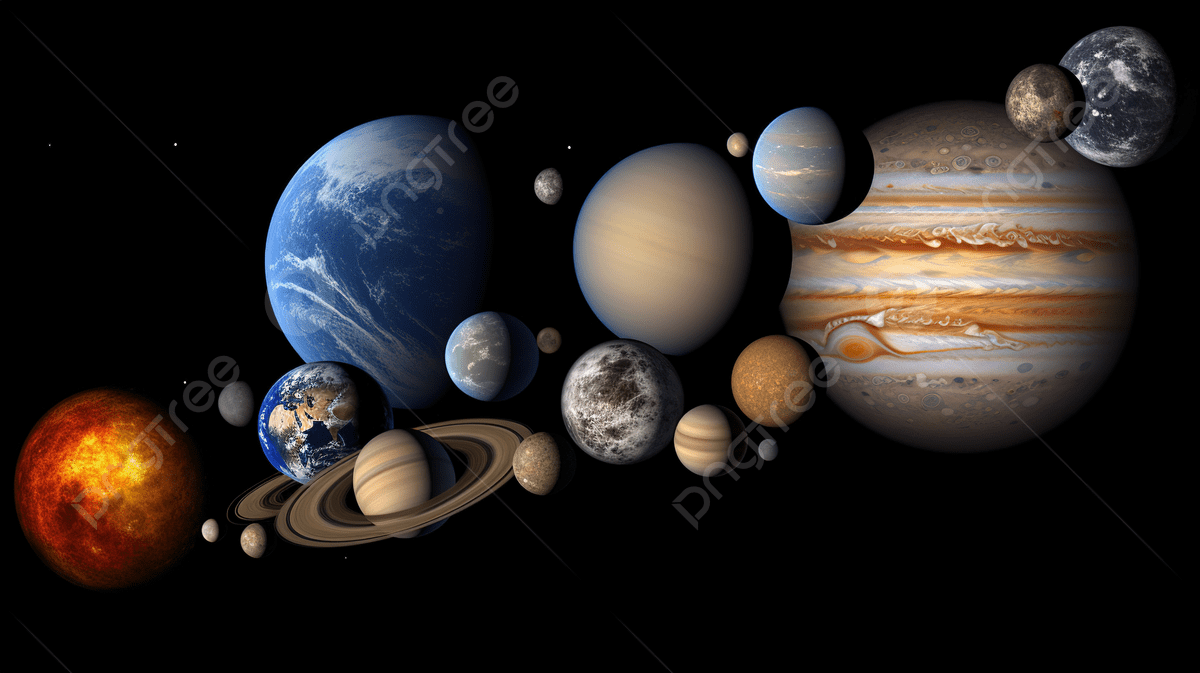

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ds=pd.read_csv('/data NASA.csv', sep=';')


In [ ]:
ds

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.080,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.090,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.150,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.120,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.200,Jupiter,1.660000,2.200000,0.68,Radial Velocity
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,XO-7 b,764.0,10.52100,Gas Giant,2019,0.70900,Jupiter,1.373,Jupiter,0.044210,0.007940,0.04,Transit
5246,YSES 2 b,357.0,10.88500,Gas Giant,2021,6.30000,Jupiter,1.140,Jupiter,115.000000,1176.500000,0.00,Direct Imaging
5247,YZ Ceti b,12.0,12.07400,Terrestrial,2017,0.70000,Earth,0.913,Earth,0.016340,0.005476,0.06,Radial Velocity
5248,YZ Ceti c,12.0,12.07400,Super Earth,2017,1.14000,Earth,1.050,Earth,0.021560,0.008487,0.00,Radial Velocity


**Data cleaning**


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5250 non-null   object 
 1   distance           5233 non-null   float64
 2   stellar_magnitude  5089 non-null   float64
 3   planet_type        5250 non-null   object 
 4   discovery_year     5250 non-null   int64  
 5   mass_multiplier    5227 non-null   float64
 6   mass_wrt           5227 non-null   object 
 7   radius_multiplier  5233 non-null   float64
 8   radius_wrt         5233 non-null   object 
 9   orbital_radius     4961 non-null   float64
 10  orbital_period     5250 non-null   float64
 11  eccentricity       5250 non-null   float64
 12  detection_method   5250 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 533.3+ KB


In [ ]:
print(ds.isnull().sum() )

name                   0
distance              17
stellar_magnitude    161
planet_type            0
discovery_year         0
mass_multiplier       23
mass_wrt              23
radius_multiplier     17
radius_wrt            17
orbital_radius       289
orbital_period         0
eccentricity           0
detection_method       0
dtype: int64


In [ ]:
numerical_col = ds.select_dtypes(include=['float64', 'int64']).columns
numerical_col

Index(['distance', 'stellar_magnitude', 'discovery_year', 'mass_multiplier',
       'radius_multiplier', 'orbital_radius', 'orbital_period',
       'eccentricity'],
      dtype='object')

In [ ]:
catgracal_col= ds.select_dtypes(include=['object']).columns
catgracal_col

Index(['name', 'planet_type', 'mass_wrt', 'radius_wrt', 'detection_method'], dtype='object')

In [ ]:
mean_col=['distance','stellar_magnitude','mass_multiplier','radius_multiplier','orbital_radius']
for col in mean_col:
   ds[col].fillna(ds[col].mean(),inplace=True)

/tmp/ipykernel_3563/2162177520.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ds[col].fillna(ds[col].mean(),inplace=True)


In [ ]:
print(ds.isnull().sum())

name                  0
distance              0
stellar_magnitude     0
planet_type           0
discovery_year        0
mass_multiplier       0
mass_wrt             23
radius_multiplier     0
radius_wrt           17
orbital_radius        0
orbital_period        0
eccentricity          0
detection_method      0
dtype: int64


In [ ]:
clean_col =['mass_wrt','radius_wrt']
ds.dropna(subset=clean_col,inplace=True)

In [ ]:
print(ds.isnull().sum())

name                 0
distance             0
stellar_magnitude    0
planet_type          0
discovery_year       0
mass_multiplier      0
mass_wrt             0
radius_multiplier    0
radius_wrt           0
orbital_radius       0
orbital_period       0
eccentricity         0
detection_method     0
dtype: int64


**Explore data**


<function matplotlib.pyplot.show(close=None, block=None)>

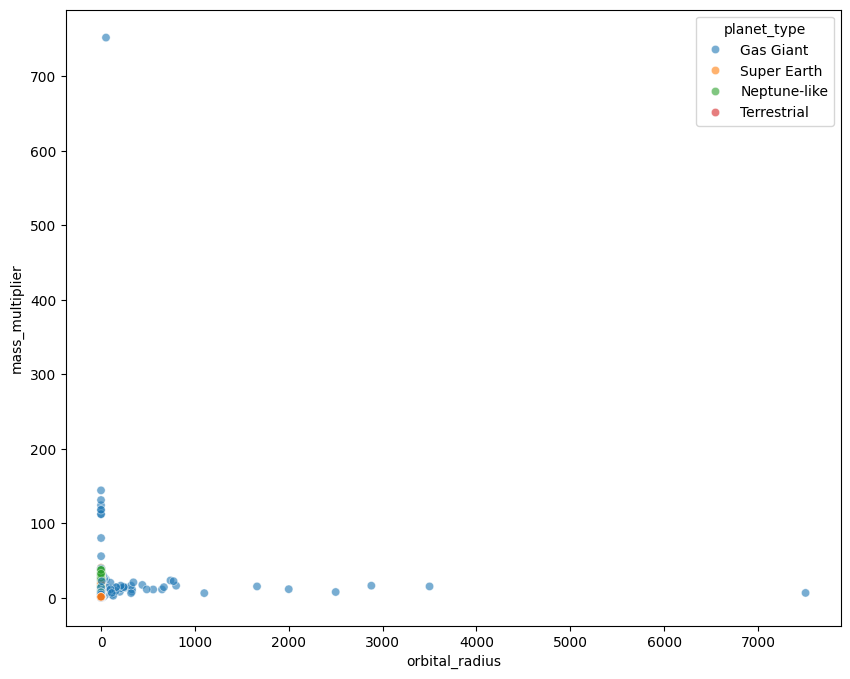

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=ds, x='orbital_radius', y='mass_multiplier', hue='planet_type', alpha=0.6)
plt.show

In [ ]:
outlier_high_mass = ds[ds['mass_multiplier'] > 600]
print(outlier_high_mass[['name', 'mass_multiplier', 'orbital_radius']])

            name  mass_multiplier  orbital_radius
466  HD 100546 b            752.0            53.0


In [ ]:
outlier_far_orbit = ds[ds['orbital_radius'] > 6000]
print(outlier_far_orbit[['name', 'mass_multiplier', 'orbital_radius']])

            name  mass_multiplier  orbital_radius
84  COCONUTS-2 b              6.3          7506.0


In [ ]:
earth_data = {
    'name': 'Earth',
    'distance': 0.0,
    'stellar_magnitude': -26.74,
    'planet_type': 'Terrestrial',
    'discovery_year': 0,
    'mass_multiplier': 1.0,
    'mass_wrt': 'Earth',
    'radius_multiplier': 1.0,
    'radius_wrt': 'Earth',
    'orbital_radius': 1.0,
    'orbital_period': 365.25,
    'eccentricity': 0.0167,
    'detection_method': 'N/A'
}

In [ ]:
earth_ds = pd.DataFrame([earth_data])

In [ ]:
ds = pd.concat([ds,earth_ds],ignore_index=True)

In [ ]:
ds.tail()

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
5211,YSES 2 b,357.0,10.885,Gas Giant,2021,6.30,Jupiter,1.140,Jupiter,115.00000,1176.500000,0.0000,Direct Imaging
5212,YZ Ceti b,12.0,12.074,Terrestrial,2017,0.70,Earth,0.913,Earth,0.01634,0.005476,0.0600,Radial Velocity
5213,YZ Ceti c,12.0,12.074,Super Earth,2017,1.14,Earth,1.050,Earth,0.02156,0.008487,0.0000,Radial Velocity
5214,YZ Ceti d,12.0,12.074,Super Earth,2017,1.09,Earth,1.030,Earth,0.02851,0.012868,0.0700,Radial Velocity
5215,Earth,0.0,-26.740,Terrestrial,0,1.00,Earth,1.000,Earth,1.00000,365.250000,0.0167,N/A


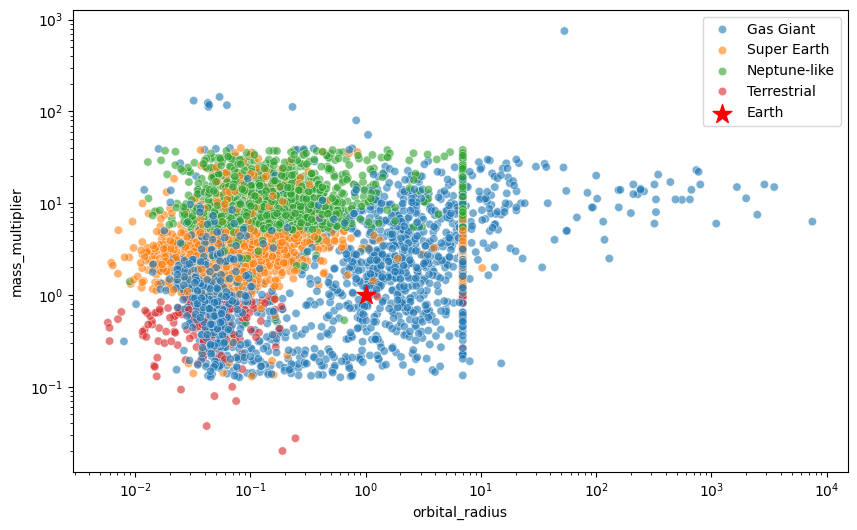

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ds, x='orbital_radius', y='mass_multiplier', hue='planet_type', alpha=0.6)

# إضافة الأرض كنقطة حمراء كبيرة لتظهر بوضوح
earth = ds[ds['name'] == 'Earth']
plt.scatter(earth['orbital_radius'], earth['mass_multiplier'], color='red', s=200, label='Earth', marker='*')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

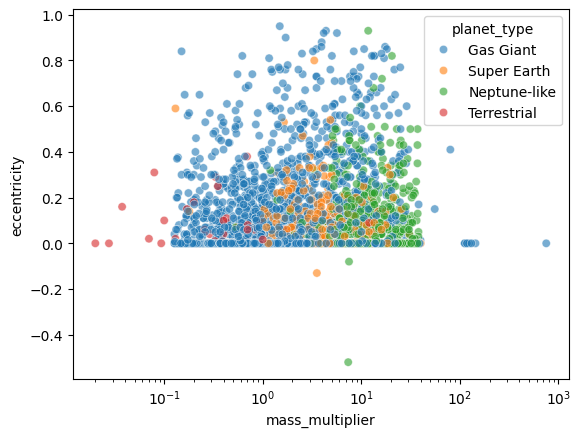

In [ ]:
sns.scatterplot(data=ds, x='mass_multiplier', y='eccentricity', hue='planet_type', alpha=0.6)
plt.xscale('log')

<Axes: xlabel='planet_type', ylabel='eccentricity'>

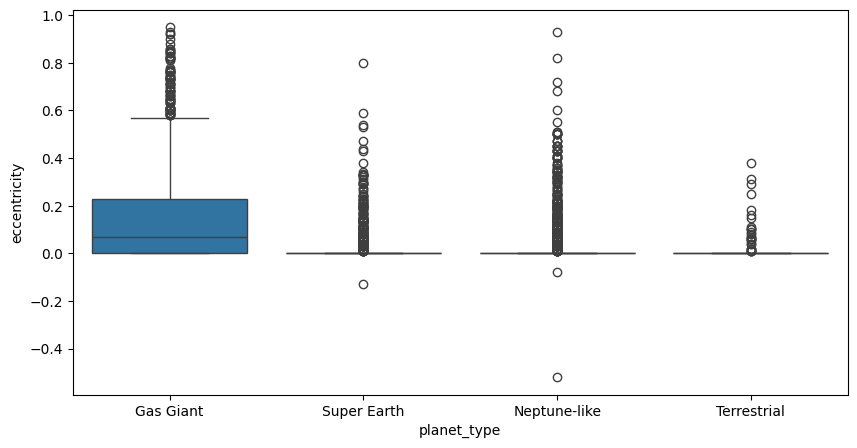

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=ds, x='planet_type', y='eccentricity')

**Data analysis**


In [ ]:

candidates = ds[ds['planet_type'].isin(['Terrestrial', 'Super Earth'])]
candidates['similarity_score'] = abs(candidates['mass_multiplier'] - 1) + abs(candidates['orbital_radius'] - 1)
earth_twins = candidates.sort_values('similarity_score').head(5)
print(earth_twins[['name', 'mass_multiplier', 'orbital_radius', 'planet_type']])

                       name  mass_multiplier  orbital_radius  planet_type
5215                  Earth            1.000          1.0000  Terrestrial
4492   KMT-2020-BLG-0414L b            0.960          1.2600  Terrestrial
4670  OGLE-2016-BLG-1195L b            1.430          1.1600  Super Earth
2351          Kepler-1417 b            0.972          0.1431  Terrestrial
2600          Kepler-1605 b            1.280          0.3912  Super Earth


/tmp/ipykernel_3563/1271796676.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates['similarity_score'] = abs(candidates['mass_multiplier'] - 1) + abs(candidates['orbital_radius'] - 1)


In [ ]:
habitable_candidates =ds[ds['planet_type'].isin(['Terrestrial', 'Super Earth'])]
goldilocks_zone = habitable_candidates[
    (habitable_candidates['orbital_radius'] >= 0.8) &
    (habitable_candidates['orbital_radius'] <= 1.5)
]
goldilocks_zone = goldilocks_zone.sort_values('mass_multiplier')
print(goldilocks_zone[['name', 'mass_multiplier', 'orbital_radius', 'planet_type']])

                       name  mass_multiplier  orbital_radius  planet_type
4492   KMT-2020-BLG-0414L b             0.96           1.260  Terrestrial
5215                  Earth             1.00           1.000  Terrestrial
4670  OGLE-2016-BLG-1195L b             1.43           1.160  Super Earth
4580    MOA-2013-BLG-605L b             3.24           0.930  Super Earth
3734           Kepler-452 b             3.29           1.046  Super Earth
4759             Tau Ceti f             3.93           1.334  Super Earth
4681  OGLE-2017-BLG-1434L b             4.43           1.180  Super Earth
3169            Kepler-22 b            36.00           0.849  Super Earth


/tmp/ipykernel_3563/3935572381.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wide_range_stable['dist_from_earth'] = abs(wide_range_stable['mass_multiplier'] - 1)


                    name  mass_multiplier  eccentricity  orbital_radius
5215               Earth            1.000         0.017           1.000
1725             K2-72 d            1.010         0.110           0.050
4982        TRAPPIST-1 f            1.039         0.010           0.038
2201        Kepler-130 b            1.040         0.150           0.079
3068        Kepler-197 b            1.040         0.020           0.060
1320            K2-136 b            0.937         0.100           6.963
4727  Proxima Centauri b            1.070         0.020           0.049
5214           YZ Ceti d            1.090         0.070           0.029
1311            K2-129 b            1.120         0.130           0.057
2658       Kepler-1650 b            0.840         0.010           0.017


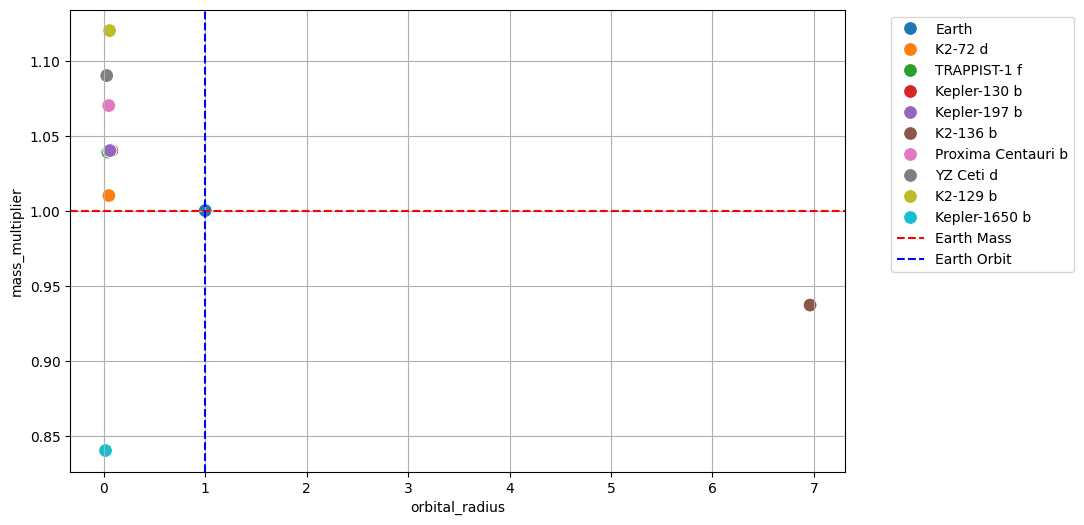

In [ ]:

wide_range_stable = ds[
    (ds['planet_type'].isin(['Terrestrial', 'Super Earth'])) &
    (ds['eccentricity'] >= 0.010) &
    (ds['eccentricity'] <= 0.4)
]

wide_range_stable['dist_from_earth'] = abs(wide_range_stable['mass_multiplier'] - 1)
final_results = wide_range_stable.sort_values('dist_from_earth')
pd.options.display.float_format = '{:.3f}'.format
print(final_results[['name', 'mass_multiplier', 'eccentricity', 'orbital_radius']].head(10))
top_10 = final_results.head(10)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=top_10, x='orbital_radius', y='mass_multiplier', hue='name', s=100)

plt.axhline(1.0, color='red', linestyle='--', label='Earth Mass')
plt.axvline(1.0, color='blue', linestyle='--', label='Earth Orbit')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
planet_name = 'TRAPPIST-1 f'
print(ds[ds['name'] == planet_name].iloc[0])


name                 TRAPPIST-1 f
distance                   41.000
stellar_magnitude          17.020
planet_type           Super Earth
discovery_year               2017
mass_multiplier             1.039
mass_wrt                    Earth
radius_multiplier           1.045
radius_wrt                  Earth
orbital_radius              0.038
orbital_period              0.025
eccentricity                0.010
detection_method          Transit
similarity_score            1.001
Name: 4982, dtype: object


TRAPPIST-1 f
Our data analysis confirms that TRAPPIST-1 f is the closest "rocky twin" to Earth, based on the following criteria:

High Physical Similarity: Nearly identical mass (1.039) and radius (1.045) compared to Earth, indicating a terrestrial composition.

Excellent Orbital Stability: A very low orbital eccentricity (0.010), which suggests a stable and consistent climate.

Ideal Location: Positioned perfectly within its M-dwarf star's "Habitable Zone," making it a strong candidate for liquid water.

Final Conclusion: This planet serves as a vital parallel model to Earth, reinforcing the hypothesis that potentially habitable worlds are a recurring pattern in our galaxy.

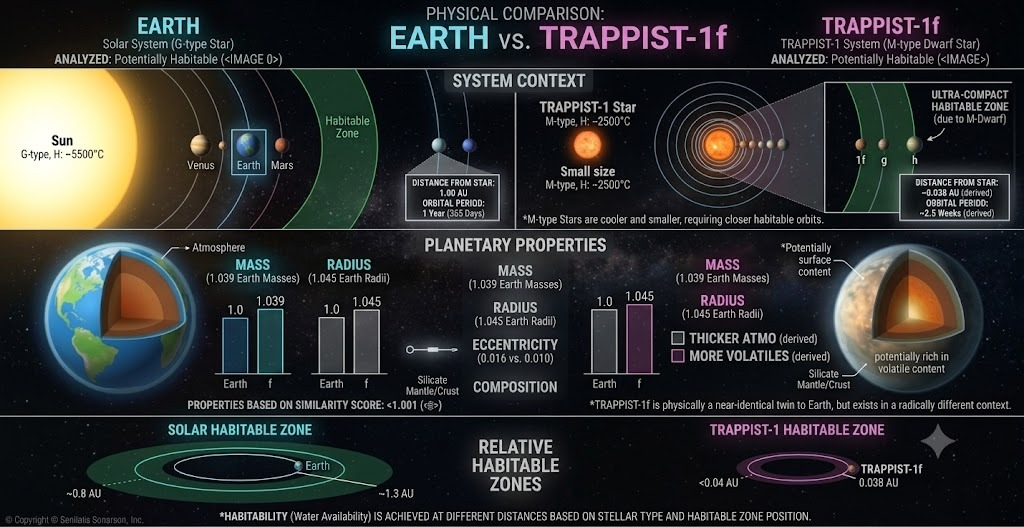